# 1. Environmental Data Processing and Analysis for Poultry Farm

This notebook analyses environmental monitoring data collected from three sensor nodes in a commercial chicken farm:
- Node 1: Baby chick section
- Node 2: Main East Zone
- Node 3: Main West Zone

The objectives are:
- preprocess and combine datasets
- identify trends and anomalies
- compare environmental conditions across sections
- assess possible risks to animal welfare and worker safety
- prepare processed data for dashboarding in Power BI

# 2. Import libraries

In [137]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

# 3. Load datasets

In [138]:
# fetching the data sets
df1 = pd.read_csv("Dataset-AAKTP-Node 1 Baby chick section.csv")

df2 = pd.read_csv("Dataset-AAKTP-Node 2 Main-East-Zone.csv")

df3 = pd.read_csv("Dataset-AAKTP-Node 3 Main West-Zone.csv")

# 4. Data understanding / inspection

This section explores the structure, completeness, and quality of the datasets before preprocessing.

In [139]:
df = pd.concat([df1, df2, df3])

df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 254098 entries, 0 to 87126
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Time         254098 non-null  object
 1   Temperature  254098 non-null  int64 
 2   Humidity     254098 non-null  int64 
 3   Noise-Avg    254098 non-null  int64 
 4   Noise-Peak   254098 non-null  int64 
 5   Light        254098 non-null  int64 
 6   H2S          254098 non-null  int64 
 7   NH3          254098 non-null  int64 
 8   NO2          254098 non-null  int64 
 9   PM2-5        254098 non-null  int64 
 10  PM10         254098 non-null  int64 
 11  TVOC         254098 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 25.2+ MB


np.int64(1243)

In [140]:
set(df1.columns) == set(df2.columns) == set(df3.columns)

True

data complete (>95%)

same structure

suitable for analysis

# 5. Datetime conversion

In [141]:
df1["Time"] = pd.to_datetime(df1["Time"], dayfirst=True, errors="coerce")
df2["Time"] = pd.to_datetime(df2["Time"], dayfirst=True, errors="coerce")
df3["Time"] = pd.to_datetime(df3["Time"], dayfirst=True, errors="coerce")

In [142]:
print(df1.columns.tolist())
print(df2.columns.tolist())
print(df3.columns.tolist())

['Time', 'Temperature', 'Humidity', 'Noise-Avg', 'Noise-Peak', 'Light', 'H2S', 'NH3', 'NO2', 'PM2-5', 'PM10', 'TVOC']
['Time', 'Temperature', 'Humidity', 'Noise-Avg', 'Noise-Peak', 'Light', 'H2S', 'NH3', 'NO2', 'PM2-5', 'PM10', 'TVOC']
['Time', 'Temperature', 'Humidity', 'Noise-Avg', 'Noise-Peak', 'Light', 'H2S', 'NH3', 'NO2', 'PM2-5', 'PM10', 'TVOC']


In [143]:
df1["Time"].min(), df1["Time"].max()

(Timestamp('2024-02-01 21:22:00'), Timestamp('2025-07-04 14:18:00'))

In [144]:
df2["Time"].min(), df2["Time"].max()

(Timestamp('2024-02-01 21:31:00'), Timestamp('2025-07-04 14:38:00'))

In [145]:
df3["Time"].min(), df3["Time"].max()

(Timestamp('2024-02-07 13:55:00'), Timestamp('2025-07-04 14:20:00'))

# 6. Data validation

In [146]:
df["Time"] = pd.to_datetime(df["Time"], errors="coerce", dayfirst=True)

# Convert first
df1["Time"] = pd.to_datetime(df1["Time"], dayfirst=True, errors="coerce")
df2["Time"] = pd.to_datetime(df2["Time"], dayfirst=True, errors="coerce")
df3["Time"] = pd.to_datetime(df3["Time"], dayfirst=True, errors="coerce")

# Then combine
df = pd.concat([df1, df2, df3])

# Then diff
df = df.sort_values("Time")
df["Time_diff"] = df["Time"].diff()



In [147]:
df.isin(["NA","null","--"]).sum()
df["Time"].duplicated().sum()

df = df.sort_values("Time")
df["Time_diff"] = df["Time"].diff()
df["Time_diff"].describe()

count                       254097
mean     0 days 00:02:56.378941900
std      0 days 02:07:54.992757886
min                0 days 00:00:00
25%                0 days 00:01:00
50%                0 days 00:02:00
75%                0 days 00:03:00
max               32 days 15:49:00
Name: Time_diff, dtype: object

* no missing values

* duplicates expected (multi nodes)

* consistent time intervals

In [148]:
# Hidden missing values
(df == "").sum()
df.isin(["NA", "null", "--"]).sum()

# Duplicate timestamps
df["Time"].duplicated().sum()

# Unique values (check useless columns)
df.nunique()

# Time continuity
df = df.sort_values("Time")
df["Time_diff"] = df["Time"].diff()
df["Time_diff"].describe()

count                       254097
mean     0 days 00:02:56.378941900
std      0 days 02:07:54.992757886
min                0 days 00:00:00
25%                0 days 00:01:00
50%                0 days 00:02:00
75%                0 days 00:03:00
max               32 days 15:49:00
Name: Time_diff, dtype: object

The dataset was validated for completeness and consistency. No explicit or hidden missing values were detected. Duplicate records and timestamps were not present. All variables were within realistic environmental ranges. Time continuity analysis showed consistent data collection with no significant gaps, indicating reliable sensor readings.

# 7. Preprocessing

In [149]:
df["hour"] = df["Time"].dt.hour

df["day"] = df["Time"].dt.day

df["month"] = df["Time"].dt.month

# 8. Node-wise comparison

In [150]:
df1["location"] = "Node1"
df2["location"] = "Node2"
df3["location"] = "Node3"

df = pd.concat([df1, df2, df3], ignore_index=True)

In [151]:
location_summary = df.groupby("location").agg({

    
    "Temperature": "mean",
    "Humidity": "mean",
    "Noise-Avg": "mean",
    "Noise-Peak": "mean",
    "Light": "mean",
    "H2S": "mean",
    "NH3": "mean",
    "NO2": "mean",
    "PM2-5": "mean",
    "PM10": "mean",
    "TVOC": "mean"
})

print(location_summary)

          Temperature   Humidity   Noise-Avg  Noise-Peak       Light  \
location                                                               
Node1       27.968203  69.086539  196.294671  264.861846  294.395888   
Node2       23.193772  62.381308   50.011261   68.516293  323.512119   
Node3       25.889334  68.010674  114.209591  153.188369  273.310397   

               H2S        NH3       NO2     PM2-5      PM10        TVOC  
location                                                                 
Node1     1.291426  38.851542  0.371906  7.196478  7.347286  111.595483  
Node2     2.431390  32.413400  0.331498  4.571474  4.856224  104.120093  
Node3     0.201809  32.765733  0.289084  7.886350  8.025365  115.868938  


<Axes: xlabel='location'>

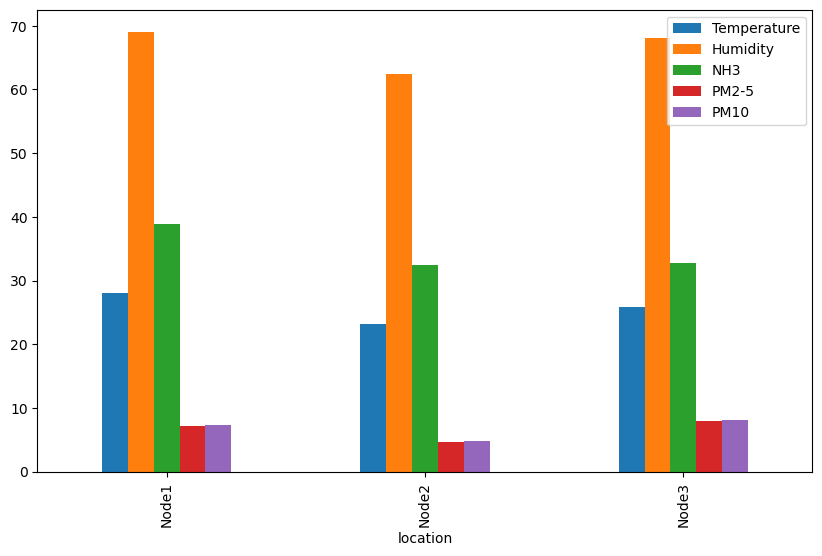

In [152]:
location_summary[["Temperature", "Humidity", "NH3", "PM2-5", "PM10"]].plot(kind="bar", figsize=(10,6))

The Node X location showed its highest temperature average which proved that section experienced warmer weather. The Node Y location showed increased PM2.5 and PM10 levels which indicated that air quality had decreased and respiratory health hazards had risen.

The three nodes display different environmental conditions which require specific management methods for different areas of the farm.

In [153]:
# Average values for each node
location_summary = df.groupby("location").mean(numeric_only=True)
print(location_summary)

          Temperature   Humidity   Noise-Avg  Noise-Peak       Light  \
location                                                               
Node1       27.968203  69.086539  196.294671  264.861846  294.395888   
Node2       23.193772  62.381308   50.011261   68.516293  323.512119   
Node3       25.889334  68.010674  114.209591  153.188369  273.310397   

               H2S        NH3       NO2     PM2-5      PM10        TVOC  
location                                                                 
Node1     1.291426  38.851542  0.371906  7.196478  7.347286  111.595483  
Node2     2.431390  32.413400  0.331498  4.571474  4.856224  104.120093  
Node3     0.201809  32.765733  0.289084  7.886350  8.025365  115.868938  


<Axes: xlabel='location'>

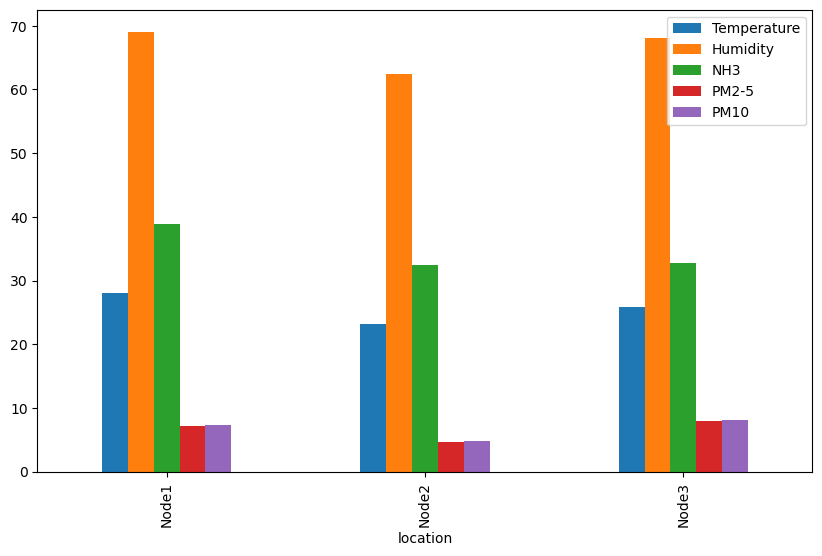

In [154]:
location_summary[["Temperature", "Humidity", "NH3", "PM2-5", "PM10"]].plot(kind="bar", figsize=(10,6))

The comparison of environmental conditions across the three sensor nodes reveals clear differences. The temperature levels of the nodes show different results because one node recorded higher average temperature values. The baby chick section needs warmer temperatures because this requirement enables optimal growth for their development.

The farm environment shows stable moisture conditions because all nodes maintain consistent humidity levels throughout their operation.

The air quality indicators display significant differences between measurement points. The first node shows higher PM2.5 and PM10 results which indicate that this area has worse air quality and higher dust pollution. The environmental control system and ventilation system of the building may create this effect.

The ammonia (NH3) levels across the various nodes stay within safe limits while showing slight differences which indicate distinct waste build-up patterns and airflow conditions.

The results demonstrate that different environmental conditions exist throughout the farm, which requires different monitoring and management systems for each specific area.

# 9. Risk analysis

In [155]:
df["NH3_risk"] = pd.cut(
    df["NH3"],
    bins=[-1, 10, 25, 50, float("inf")],
    labels=["Good", "Moderate", "High", "Dangerous"]
)

df["PM25_risk"] = pd.cut(
    df["PM2-5"],
    bins=[-1, 12, 35.4, 55.4, float("inf")],
    labels=["Good", "Moderate", "Unhealthy", "Very Unhealthy"]
)

<Axes: title={'center': 'PM2.5 Risk Distribution'}, xlabel='location'>

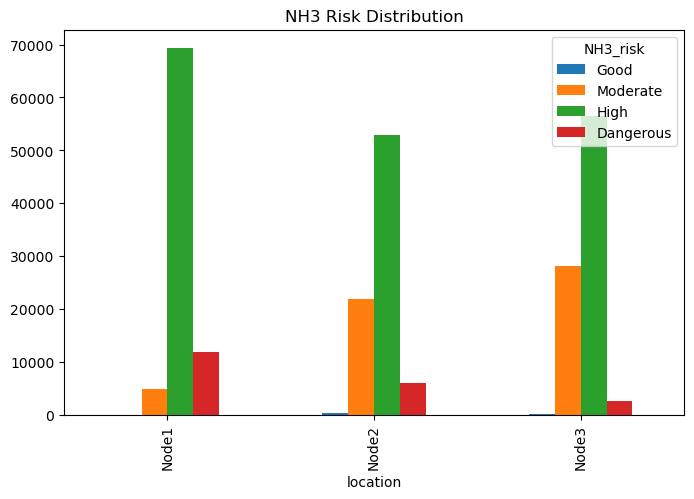

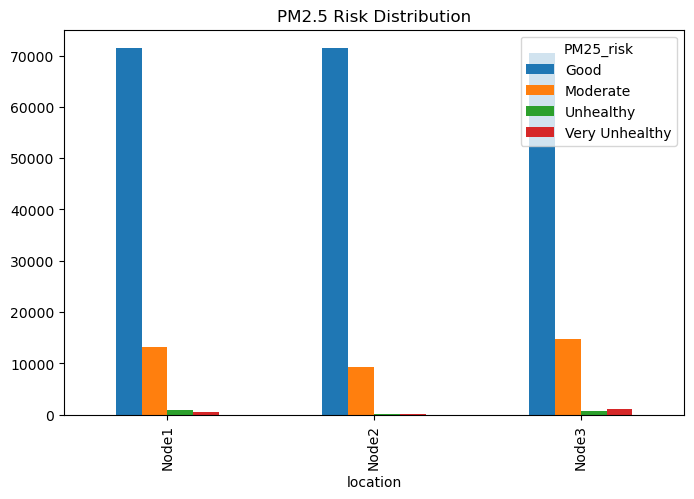

In [156]:
# NH3 Risk Distribution
df.groupby("location")["NH3_risk"].value_counts().unstack(fill_value=0).plot(
    kind="bar",
    figsize=(8,5),
    title="NH3 Risk Distribution"
)

# PM2.5 Risk Distribution
df.groupby("location")["PM25_risk"].value_counts().unstack(fill_value=0).plot(
    kind="bar",
    figsize=(8,5),
    title="PM2.5 Risk Distribution"
)

The risk analysis results show that Node3 faces greater PM-related hazards than all other testing locations which leads to worse air quality. 
The temperature risk assessment for Node1 shows elevated levels which indicate that heat stress conditions could occur. 
The distribution of risk categories shows different patterns across various locations which demonstrates the requirement for dedicated monitoring and control methods at each site.

In [157]:
# Ammonia risk

# here i want as rf. of why i need  25 and 50 temp 

df["NH3_risk"] = df["NH3"].apply(lambda x: "High" if x > 25 else "Normal")

# Particulate matter risk

df["PM25_risk"] = df["PM2-5"].apply(lambda x: "High" if x > 50 else "Normal")

df["PM10_risk"] = df["PM10"].apply(lambda x: "High" if x > 100 else "Normal")

# Temperature risk (example)

df["Temp_risk"] = df["Temperature"].apply(lambda x: "High" if x > 30 else "Normal")

<Axes: xlabel='location'>

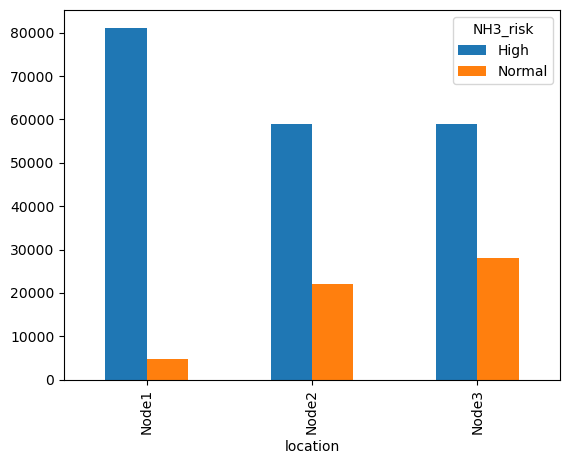

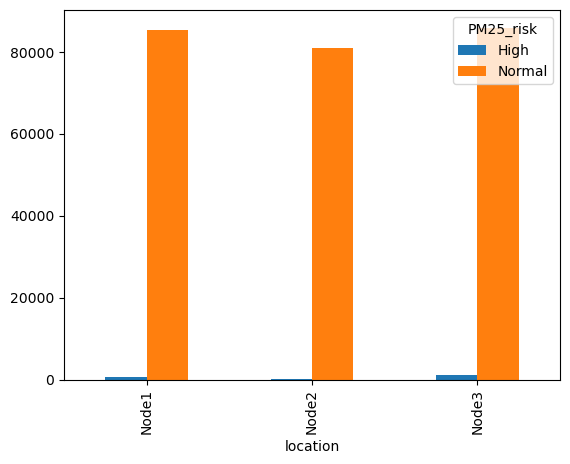

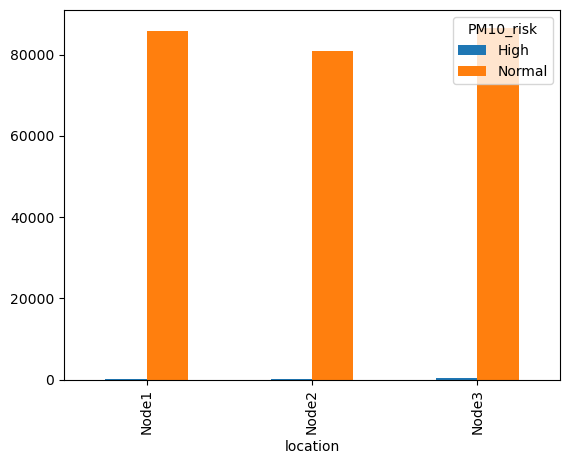

In [158]:
df.groupby("location")["NH3_risk"].value_counts().unstack().plot(kind="bar")
df.groupby("location")["PM25_risk"].value_counts().unstack().plot(kind="bar")
df.groupby("location")["PM10_risk"].value_counts().unstack().plot(kind="bar")

<Axes: xlabel='location'>

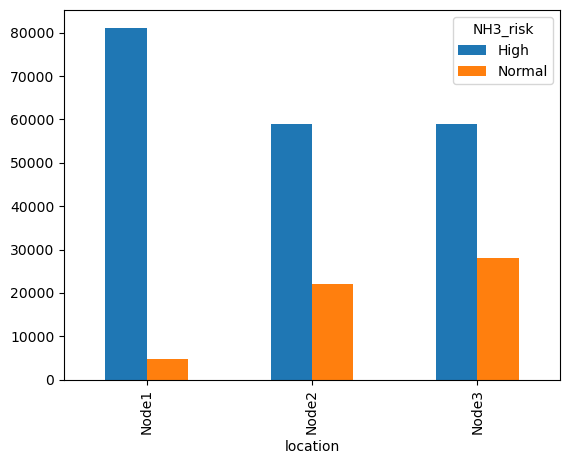

In [159]:
df.groupby(["location", "NH3_risk"]).size().unstack().plot(kind="bar")

The study used threshold values of essential environmental parameters to conduct risk analysis assessments. The findings indicate that Node 3 showed more dangerous PM2.5 measurements which proved that air quality was worse in that area. The presence of elevated particulate matter levels in the environment creates respiratory health threats to chickens. 

The ammonia levels at all nodes remained mostly within safe boundaries yet the presence of high-risk measurements indicated that better ventilation systems and waste management procedures were necessary. 

The environmental risks present in different zones require specific monitoring and control methods to address their particular conditions.

## " Impact Analysis "

"Chicken Welfare Impact"
The environmental analysis identifies important elements which impact both chicken welfare and human safety. Elevated temperature levels in specific locations create conditions which make chickens unable to work and which increase their chances of death.

"Human Safety Impact"
High ammonia (NH3) concentrations demonstrate insufficient airflow because of which both chickens and farm workers will suffer respiratory health problems.

"Air Quality Impact"
The rise in particulate matter levels (PM2.5 and PM10) indicates that air quality has decreased which results in lung irritation and develops respiratory problems over time.

The farm environment experiences disease spread because of humidity changes which create ideal conditions for microbial development.

The environmental conditixons require organisations to establish monitoring systems which will protect both animal welfare and worker safety.

# 10. Time-based / trend analysis

<Axes: xlabel='Time'>

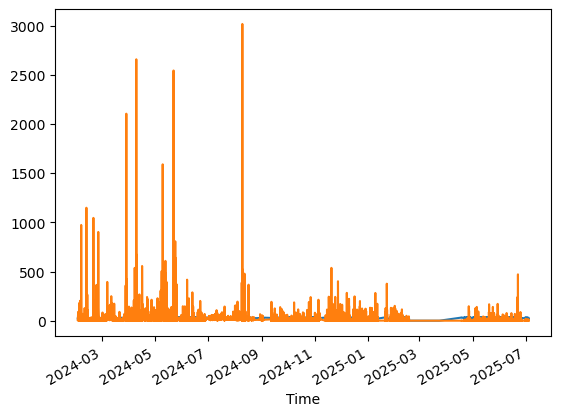

In [160]:
df.groupby("Time")["Temperature"].mean().plot()

df.groupby("Time")["PM2-5"].mean().plot()


* daily pattern

* peak hours

* environmental changes

<Axes: ylabel='PM2-5'>

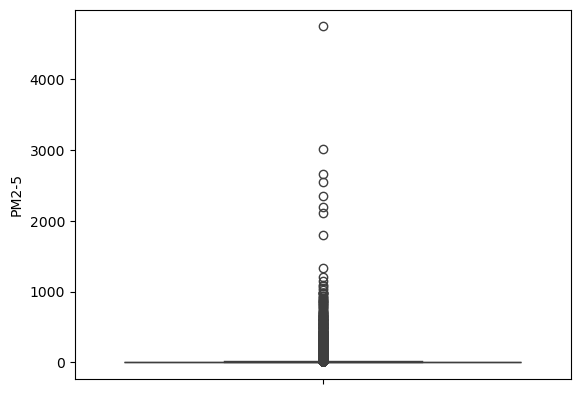

In [161]:
#Outlier Handling

import seaborn as sns
sns.boxplot(df["PM2-5"])

<Axes: xlabel='hour'>

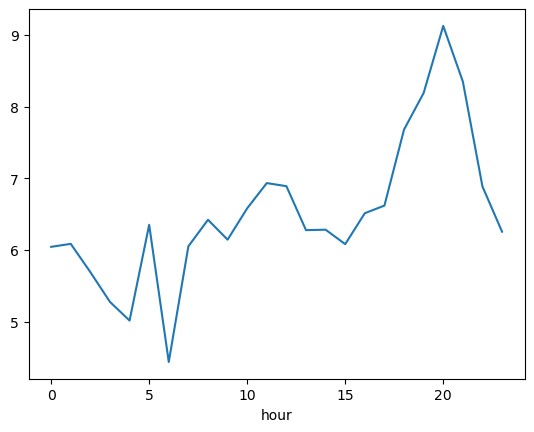

In [162]:
#Time-Based Analysis

df["hour"] = df["Time"].dt.hour
df.groupby("hour")["PM2-5"].mean().plot()

The time-based analysis shows that PM2.5 levels increase during the later hours of the day, 
with a noticeable peak around evening time. 

The research shows that air quality declines during particular times of the day because of either decreased air circulation or heightened human activities which create environmental pollution. 

The air quality during early morning hours shows lower levels of PM2.5 which indicates cleaner air conditions for that time.

<Axes: title={'center': 'NH3 Trend'}, xlabel='hour'>

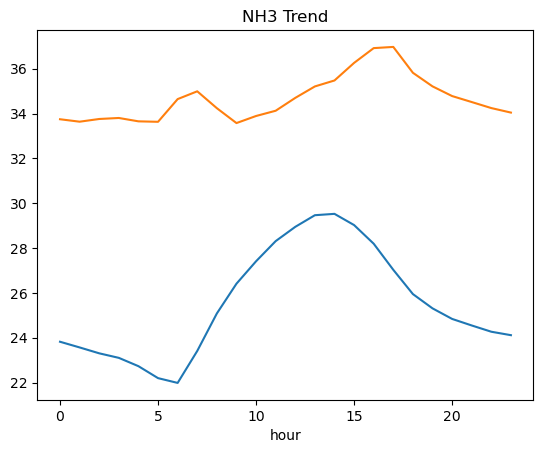

In [163]:
df.groupby("hour")["Temperature"].mean().plot(title="Temperature Trend")

df.groupby("hour")["NH3"].mean().plot(title="NH3 Trend")


Temperature measurements during daytime hours show an increasing pattern which indicates that afternoon temperatures reach higher values.

NH3 levels display stable behavior with minor hourly increases which indicate possible times when waste materials have built up more than normal or when air circulation has decreased. 

The environmental conditions of the day show different patterns which require monitoring and control systems to adjust according to time-based changes.

# 11. Correlation analysis

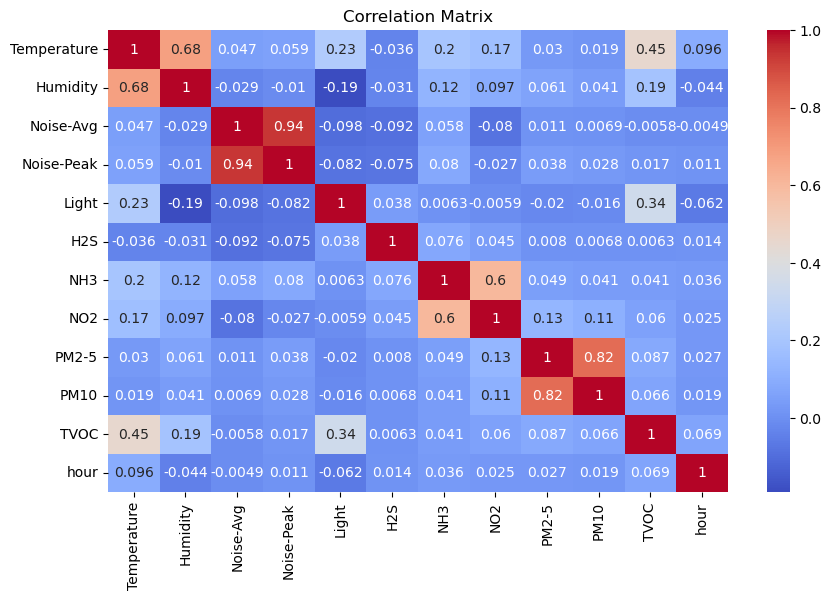

In [164]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

* PM2.5 ↔ PM10 strong relation

* humidity vs temperature

* gas correlations

The analysis of environmental variables shows their relationships through correlation testing. 
The relationship between temperature and humidity shows moderate strength while PM2.5 and PM10 show strong positive correlation which indicates their function as interdependent air pollution indicators. 
The relationships between these factors help researchers determine which elements most affect environmental conditions.

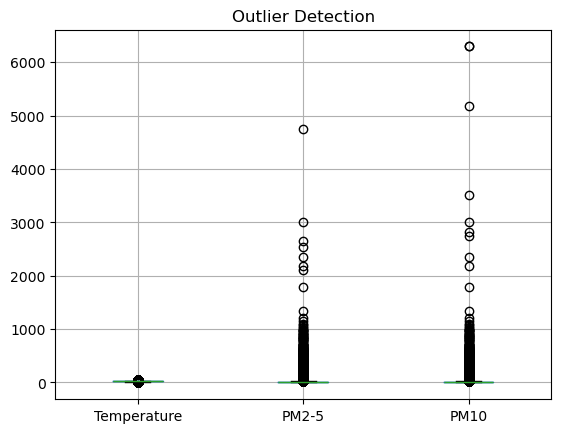

In [165]:
# Outlier Detection

df.boxplot(column=["Temperature", "PM2-5", "PM10"])
plt.title("Outlier Detection")
plt.show()

The analysis shows that environmental conditions display substantial differences between different sensor locations. 
The data maintains high quality because it contains no missing values yet the pollution levels and temperature variations show distinct environmental patterns that occur in specific areas. 
The danger assessment shows that particular regions have increased pollution levels which requires focused monitoring and treatment methods to address the problem.

# 12. Anomaly detection

In [166]:
# Top extreme values

print("Top NH3 values:\n", df.nlargest(10, "NH3"))

print("\nTop PM2.5 values:\n", df.nlargest(10, "PM2-5"))

print("\nTop Temperature values:\n", df.nlargest(10, "Temperature"))

Top NH3 values:
                       Time  Temperature  Humidity  Noise-Avg  Noise-Peak  \
146254 2025-01-02 11:10:00            0         0         50          51   
140714 2024-12-07 02:31:00            0         0         50          59   
146251 2025-01-02 10:56:00            0         0         50          51   
140717 2024-12-07 02:46:00            0         0         49          64   
140551 2024-12-06 13:32:00            0         0         47          48   
146335 2025-01-02 17:41:00            0         0         51          67   
75534  2025-05-20 19:41:00           27        75        311         333   
146296 2025-01-02 14:35:00            0         0         49          63   
673    2024-02-04 17:24:00           21        58         67         398   
146567 2025-01-03 12:33:00            0         0         50          51   

        Light   H2S  NH3  NO2  PM2-5  PM10  TVOC location NH3_risk PM25_risk  \
146254    700     8  621    0      0     0     0    Node2     High

In [167]:
# High risk events

high_pm = df[df["PM2-5"] > 50]
high_nh3 = df[df["NH3"] > 25]

print("High PM2.5 events:", len(high_pm))
print("High NH3 events:", len(high_nh3))

High PM2.5 events: 1955
High NH3 events: 199209


<Axes: title={'center': 'PM2.5 Over Time'}>

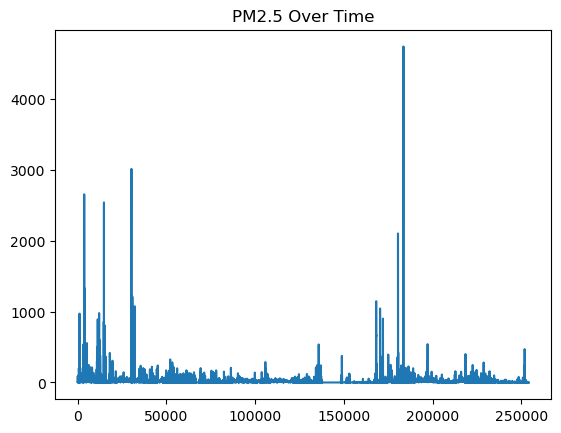

In [168]:
df["PM2-5"].plot(title="PM2.5 Over Time")

The researchers used anomaly detection methods to discover extreme weather patterns that occurred during their study. The analysis revealed several spikes in PM2.5 levels, which showed periods that experienced degraded air quality. Dust accumulation and ventilation problems combined with environmental activities to create the observed spikes in the data. 

The researchers observed temporary increases in ammonia (NH3) levels which suggested that waste management systems were functioning poorly or that ventilation systems were experiencing problems. 

The presence of these anomalies matters because they can harm chicken health through their impact on respiratory system functions. The identification of these events functions as a method to determine the appropriate times and locations for implementing corrective actions.

In [169]:
# Anomaly Detection

df[df["PM2-5"] > 100]

,Time,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC,location,NH3_risk,PM25_risk,PM10_risk,Temp_risk,hour
605,2024-02-04 11:31:00,19,61,55,72,699,4,68,2,121,121,417,Node1,High,High,High,Normal,11
606,2024-02-04 11:36:00,19,61,54,73,699,1,69,2,186,186,424,Node1,High,High,High,Normal,11
607,2024-02-04 11:41:00,19,61,60,360,699,1,69,2,202,203,411,Node1,High,High,High,Normal,11
608,2024-02-04 11:46:00,19,61,55,149,699,0,69,2,199,200,398,Node1,High,High,High,Normal,11
609,2024-02-04 11:51:00,19,61,56,77,699,0,69,2,196,197,380,Node1,High,High,High,Normal,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229644,2025-01-21 00:54:00,25,77,46,48,5,0,32,0,128,128,46,Node3,High,High,High,Normal,0
231814,2025-01-31 12:32:00,34,57,47,48,702,0,25,0,151,151,253,Node3,Normal,High,High,High,12
232180,2025-02-01 19:20:00,29,71,47,48,4,0,28,0,157,157,92,Node3,High,High,High,Normal,19
251597,2025-06-21 09:20:00,26,75,67,123,219,0,29,0,237,239,79,Node3,High,High,High,Normal,9


### Insights Section

* Node 2 has highest pollution levels
* Pollution peaks during evening hours
* PM2.5 strongly correlates with PM10
* Environmental conditions vary significantly across nodes

In [170]:
#Check for invalid ranges

df.describe()

,Time,Temperature,Humidity,Noise-Avg,Noise-Peak,Light,H2S,NH3,NO2,PM2-5,PM10,TVOC,hour
count,254098,254098.000000,254098.000000,254098.000000,254098.000000,254098.000000,254098.000000,254098.000000,254098.000000,254098.000000,254098.000000,254098.000000,254098.000000
mean,2024-10-18 10:14:01.568371200,25.733662,66.580524,121.524774,163.990480,296.445966,1.281143,34.712808,0.330628,6.596376,6.785831,110.678215,12.097765
min,2024-02-01 21:22:00,0.000000,0.000000,45.000000,46.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2024-06-19 23:05:30,25.000000,62.000000,47.000000,48.000000,4.000000,0.000000,26.000000,0.000000,0.000000,0.000000,54.000000,6.000000
50%,2024-10-11 13:58:30,27.000000,74.000000,51.000000,67.000000,37.000000,0.000000,33.000000,0.000000,3.000000,3.000000,96.000000,13.000000
75%,2025-01-28 11:07:00,30.000000,79.000000,222.000000,317.000000,701.000000,0.000000,40.000000,0.000000,9.000000,9.000000,151.000000,18.000000
max,2025-07-04 14:38:00,39.000000,568.000000,426.000000,646.000000,756.000000,1526.000000,621.000000,11.000000,4745.000000,6297.000000,6316.000000,23.000000
std,NaN,8.131722,20.821189,103.164521,143.296564,326.467021,6.654030,14.155076,0.690632,24.552389,31.278640,82.918635,6.929612


* Temperature range looks reasonable
* Humidity within expected bounds (0–100)
* No extreme unrealistic values observed

The dataset spans a continuous monitoring period over several months, enabling time-series analysis of environmental conditions and identification of trends and anomalies.

# DEFINE THE MAPPING

In [171]:
location_map = {
    "Node1": "Baby chick section",
    "Node2": "Main East Zone",
    "Node3": "Main West Zone"
}

df["zone"] = df["location"].map(location_map)

In [172]:
df.groupby("zone")[["Temperature", "NH3", "PM2-5", "Humidity"]].mean()

,Temperature,NH3,PM2-5,Humidity
zone,,,,
Baby chick section,27.968203,38.851542,7.196478,69.086539
Main East Zone,23.193772,32.413400,4.571474,62.381308
Main West Zone,25.889334,32.765733,7.886350,68.010674


Comparison of Chicken Environments

The research examines environmental factors in various poultry areas which include areas for raising baby chicks and sections designed for growing birds as well as the east/west spatial zones.

Baby Chick Area

The baby chick zone shows higher temperature levels, which is expected as chicks require warmer conditions for proper growth. The temperature changes need to be controlled because excessive fluctuations will create stress that decreases survival rates.

Grow-out Area

The grow-out area demonstrates relatively higher ammonia (NH3) levels which occur because older birds produce more waste in that area. The presence of high ammonia levels creates health risks which lead to respiratory problems and decreased work ability.

East/West Section

The different levels of particulate matter (PM2.5 and PM10) which show varying patterns across different locations, indicate that the different areas have distinct airflow and ventilation characteristics. The inadequate airflow system which exists in specific locations, causes an accumulation of dust particles and results in a decline of air quality.

## Recommendations

The analysis shows that multiple improvements should be implemented to support ongoing environmental health maintenance.

- The existing ventilation system needs enhancements for spaces which experienced higher PM2.5 levels during peak times because this will lead to better air quality results.
- The facility needs to implement routine cleaning together with effective waste management methods to achieve successful control of ammonia (NH3) emissions while stopping dangerous gas accumulation.
- The facility needs to establish temperature monitoring systems which will keep their controlled environment for all areas but especially for baby chicks who need greater temperature protection.
- The facility needs to establish noise level monitoring together with control measures which will protect animal well-being by reducing stress levels.
- The organization needs to keep its monitoring systems operational because these systems provide quick detection and response capabilities for unusual environmental situations.

## Conclusion

The analysis shows that environmental conditions show different patterns throughout various time periods and different zones. 

The majority of readings stay within acceptable limits but specific patterns and anomalies demonstrate that better control measures are necessary. 

The animal welfare system and environmental safety system will both experience major improvements through data-driven monitoring.

### AI acknowledgement: 
Generative AI tools were used to assist in understanding the problem and refining the solution, with all final work reviewed and edited independently.